/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.9560 - loss: 0.1448 - val_accuracy: 0.9833 - val_loss: 0.0537
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9856 - loss: 0.0465 - val_accuracy: 0.9842 - val_loss: 0.0476
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9898 - loss: 0.0325 - val_accuracy: 0.9872 - val_loss: 0.0406
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9923 - loss: 0.0247 - val_accuracy: 0.9893 - val_loss: 0.0363
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9945 - loss: 0.0182 - val_accuracy: 0.9904 - val_loss: 0.0276
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9955 - loss: 0.0146 - val_accuracy: 0.9908 - val_loss: 0.0287
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9961 - loss: 0.0113 - val_accuracy: 0.9903 - val_loss: 0.0392
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9970 -

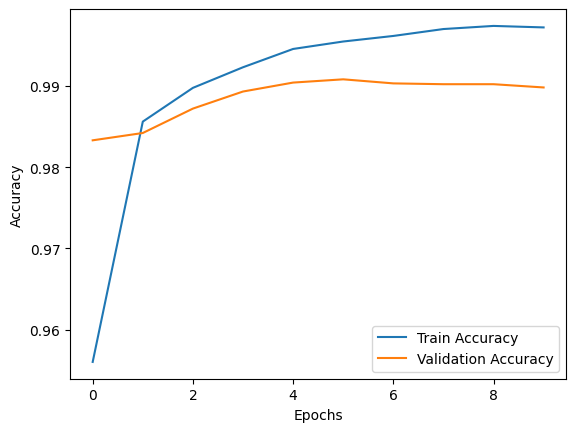

upload a digit image


Saving Screenshot 2026-05-19 192903.png to Screenshot 2026-05-19 192903.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


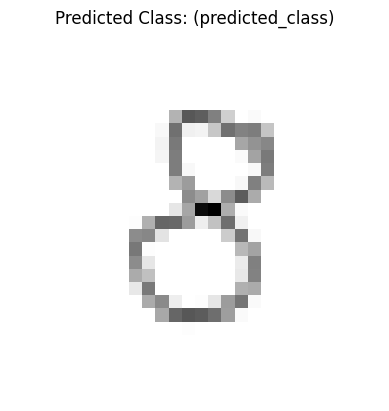

In [5]:
!pip install tensorflow matplotlib

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from PIL import Image

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy: ", test_acc)

plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print("upload a digit image")
uploaded = files.upload()
for filename in uploaded.keys():
  img = Image.open(filename).convert('L')
  img = img.resize((28,28))
  img = np.array(img) / 255.0
  img = img.reshape(1, 28, 28, 1)

  prediction = model.predict(img)
  predicted_class = np.argmax(prediction)

  plt.imshow(img.reshape(28,28), cmap='gray')
  plt.title(f"Predicted Class: (predicted_class)")
  plt.axis('off')
  plt.show()